<a href="https://colab.research.google.com/github/serenalxs/Practice/blob/main/linearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import torch

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
url = "https://raw.githubusercontent.com/serenalxs/Practice/refs/heads/main/Basic/Income1.csv"
data = pd.read_csv(url)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  30 non-null     int64  
 1   Education   30 non-null     float64
 2   Income      30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes


Data preprocess:

.values: convert to an array
.reshape(-1,1) : -1 -- auto calculation; 1: dimension

In [3]:
X = torch.from_numpy (data.Education.values.reshape(-1,1).astype(np.float32))
Y = torch.from_numpy (data.Income.values.reshape(-1,1).astype(np.float32))

X[:10]

tensor([[10.0000],
        [10.4013],
        [10.8428],
        [11.2441],
        [11.6455],
        [12.0870],
        [12.4883],
        [12.8896],
        [13.2910],
        [13.7324]])

# **Manual calculation: solve Y = WX + b**

step 1. initialize W ~N (0,1), b = 0

step 2. Learning rate = 0.00001

step 3. model ::

prediction, loss,

reset grad, otherwise grad will be cumulated; calculate new coefficient based on gradients and learning rate



In [11]:
w = torch.randn(1, requires_grad=True)
b = torch.zeros(1, requires_grad=True)

learning_rate = 0.00001

print (w)
print(b)

print("--------------")
print("grad is initialized as None")
print(w.grad)
print(b.grad)

tensor([0.3139], requires_grad=True)
tensor([0.], requires_grad=True)
--------------
grad is initialized as None
None
None


In [13]:
for epoch in range(5000) :
  for x , y in zip (X, Y) :
    y_pred = torch.matmul(x,w) + b
    loss = (y_pred - y) ** 2

    # reset w and b gradient as 0 before every time's calculation, otherwise will be cumulatively calculated
    if w.grad is not None :
      w.grad.zero_()
    if b.grad is not None :
      b.grad.zero_()

    loss.backward()

    with torch.no_grad() :
      w -= learning_rate * w.grad
      b -= learning_rate * b.grad




In [15]:
print (w.data)
print (b.data)

tensor([3.5727])
tensor([-5.0801])


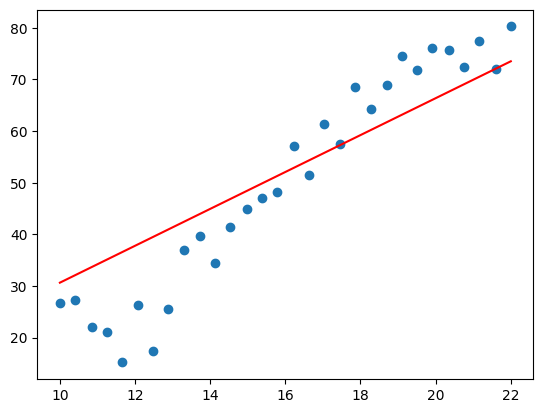

In [22]:
plt.scatter(data.Education, data.Income)
plt.plot (X.numpy(), (X*w+b).data.numpy(), c='r')